In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

from datetime import datetime, timedelta
from seaborn import set_style
set_style("whitegrid")

In [2]:
df = pd.read_csv('/Users/andreafodor/erdos_summer2025/windPower/data/final_dataframes/main_training_dataframe.csv')
df['time'] = pd.to_datetime(df['time'])
df = df.set_index('time')

In [3]:
df.sample(10)

,Unnamed: 0,temperature_2m_1,relative_humidity_2m_1,wind_speed_10m_1,wind_direction_10m_1,temperature_2m_33,relative_humidity_2m_33,wind_speed_10m_33,wind_direction_10m_33,temperature_2m_2,...,relative_humidity_2m_34,wind_speed_10m_34,wind_direction_10m_34,temperature_2m_38,relative_humidity_2m_38,wind_speed_10m_38,wind_direction_10m_38,Wind,Year,MonthDay
time,,,,,,,,,,,,,,,,,,,,,
2021-11-27 21:00:00,25485,-2.0,83,31.6,262,-3.3,78,35.0,290,-5.6,...,83,21.6,266,-4.2,77,25.2,267,2111.0,2021,11-27
2022-09-13 19:00:00,32443,21.0,79,12.7,145,20.4,91,8.8,279,15.8,...,93,12.0,123,20.6,71,10.1,197,1199.0,2022,09-13
2019-10-06 13:00:00,6685,12.1,46,10.2,212,10.4,64,11.6,150,7.8,...,48,14.9,187,12.4,43,13.4,204,1562.0,2019,10-06
2020-10-17 23:00:00,15743,5.1,88,34.6,262,3.0,76,11.6,210,1.8,...,100,28.8,268,3.3,77,18.6,252,2959.0,2020,10-17
2020-06-21 09:00:00,12897,20.0,68,6.4,128,25.0,61,4.3,90,11.6,...,79,10.4,136,19.9,76,3.1,306,241.0,2020,06-21
2021-12-06 04:00:00,25684,-11.4,80,8.6,158,-11.0,78,17.9,99,-11.9,...,87,6.6,99,-11.6,79,11.2,123,1422.0,2021,12-06
2021-12-15 13:00:00,25909,-7.5,73,11.8,282,-8.8,70,8.6,90,-9.4,...,76,14.8,309,-9.2,69,4.0,265,1122.0,2021,12-15
2022-11-06 14:00:00,33734,20.8,62,25.1,196,20.4,56,28.8,227,16.6,...,77,15.7,196,20.0,68,19.6,216,2952.0,2022,11-06
2022-06-17 14:00:00,30326,21.4,80,20.6,216,21.2,58,18.2,243,15.8,...,73,21.3,204,22.2,57,18.3,234,1425.0,2022,06-17


In [4]:
numeric_cols = df.select_dtypes(include=['int64', 'float64'])
coldict = {}
for col in numeric_cols.columns:
    if col=='Wind':
        coldict[col] = 'sum'
    else:
        coldict[col] = 'mean'

daily = numeric_cols.resample('D').agg(coldict)

daily['day_of_year'] = daily.index.dayofyear
daily['year'] = daily.index.year
daily['month'] = daily.index.month

nfarms = 0
for column in df.columns:
    if 'temperature' in column:
        nfarms += 1
        
daily['mean_temperature'] = daily[[f'temperature_2m_{i}' for i in range(1, nfarms)]].mean(axis=1)
daily['mean_humidity'] = daily[[f'relative_humidity_2m_{i}' for i in range(1, nfarms)]].mean(axis=1)
daily['mean_windspeed'] = daily[[f'wind_speed_10m_{i}' for i in range(1, nfarms)]].mean(axis=1)

        
daily.sample(10)

,Unnamed: 0,temperature_2m_1,relative_humidity_2m_1,wind_speed_10m_1,wind_direction_10m_1,temperature_2m_33,relative_humidity_2m_33,wind_speed_10m_33,wind_direction_10m_33,temperature_2m_2,...,wind_speed_10m_38,wind_direction_10m_38,Wind,Year,day_of_year,year,month,mean_temperature,mean_humidity,mean_windspeed
time,,,,,,,,,,,,,,,,,,,,,
2022-03-30,28427.5,-3.983333,70.625000,18.837500,271.833333,-7.441667,69.041667,11.058333,252.083333,-4.708333,...,14.825000,277.791667,41499.0,2022.0,89,2022,3,-5.751535,68.641447,16.247697
2022-10-19,33299.5,14.333333,91.333333,24.270833,162.875000,7.229167,85.958333,7.637500,199.416667,10.429167,...,7.895833,251.333333,34083.0,2022.0,292,2022,10,8.726645,89.821272,15.079167
2022-12-08,34499.5,0.512500,88.041667,14.837500,260.458333,-3.879167,74.833333,19.416667,307.958333,-0.250000,...,15.012500,290.125000,30896.0,2022.0,342,2022,12,-1.443092,87.239035,15.158772
2019-06-28,4283.5,15.829167,92.791667,6.604167,203.750000,19.012500,79.833333,8.175000,227.833333,13.895833,...,5.904167,253.583333,7509.0,2019.0,179,2019,6,16.609759,84.175439,7.853289
2022-07-18,31067.5,23.208333,67.458333,12.350000,236.875000,23.908333,65.166667,15.916667,213.541667,20.237500,...,12.979167,226.666667,22089.0,2022.0,199,2022,7,20.788377,70.797149,11.361623
2020-04-23,11483.5,-3.904167,64.875000,28.225000,256.500000,-4.987500,57.583333,24.562500,288.958333,-6.683333,...,24.320833,278.541667,71016.0,2020.0,114,2020,4,-5.419079,58.314693,22.157456
2021-10-03,24155.5,7.337500,91.708333,6.037500,243.875000,9.258333,77.791667,7.962500,194.666667,4.983333,...,7.029167,68.625000,8394.0,2021.0,276,2021,10,6.475439,86.255482,8.230154
2020-05-27,12299.5,16.475000,74.708333,7.191667,148.208333,20.570833,84.291667,8.120833,182.208333,13.208333,...,6.700000,206.916667,18726.0,2020.0,148,2020,5,19.201754,74.288377,9.378509
2019-01-13,299.5,-15.662500,78.541667,17.779167,255.291667,-19.758333,73.250000,8.829167,249.833333,-17.650000,...,10.645833,288.333333,30032.0,2019.0,13,2019,1,-17.858114,77.328947,13.508662


# Linear Regression

In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_percentage_error as mape


In [6]:
mlr_model = LinearRegression()

mlr_model.fit(
    daily.query('year<2022')[["mean_windspeed", "mean_temperature"]], daily.query('year<2022').Wind
)
preds = mlr_model.predict(daily.query('year==2022')[['mean_windspeed', 'mean_temperature', ]])
print(mape(daily.query('year==2022').Wind.values, preds))
print(r2_score(daily.query('year==2022').Wind.values, preds))


0.22024189884609432
0.7852878630635252


In [7]:
mlr_model = LinearRegression()

mlr_model.fit(
    daily.query('year<2022')[["mean_windspeed", "mean_temperature", 'mean_humidity']], daily.query('year<2022').Wind
)
preds = mlr_model.predict(daily.query('year==2022')[['mean_windspeed', 'mean_temperature', 'mean_humidity']])
print(mape(daily.query('year==2022').Wind.values, preds))
print(r2_score(daily.query('year==2022').Wind.values, preds))


0.21715982508628237
0.7991760122117719


In [57]:
df_wf = pd.read_csv('../data/raw_data/hydroquebec_wind_farms_in_service.csv')

In [60]:
df_wf

,name,labels,project_type,capacity_MW,region,status,commissioning_date,latitude,longitude
0,Baie-des-Sables wind farm,1,Wind farm,109.50,Bas-Saint-Laurent,In service,2006-11-22,48.702210,-67.872489
1,Carleton wind farm,2,Wind farm,109.50,Gaspésie–Îles-de-la-Madel,In service,2008-11-22,48.202737,-66.128295
2,Mont-Rothery wind farm,3,Wind farm,74.00,Gaspésie–Îles-de-la-Madel,In service,2015-12-01,48.978875,-65.373544
3,De L'Érable wind farm,4,Wind farm,100.00,Centre-du-Québec,In service,2013-11-16,46.096983,-71.647639
4,Des Moulins wind farm,5,Wind farm,156.85,Chaudière-Appalaches,In service,2013-12-07,46.173945,-71.351327
5,Frampton wind farm,6,Wind farm,24.00,Chaudière-Appalaches,In service,2015-12-15,46.438045,-70.741843
6,Gros-Morne wind farm,7,Wind farm,211.50,Gaspésie–Îles-de-la-Madel,In service,"Phase-1 : 2011-11-29, phase-2 : 2012-11-06.",49.206341,-65.448274
7,Côte-de-Beaupré wind farm,8,Wind farm,23.50,Capitale-National,In service,2015-11-19,47.311169,-70.881464
8,La Mitis wind farm,9,Wind farm,24.60,Bas-Saint-Laurent,In service,2014-10-17,48.358704,-67.821154
9,Lac-Alfred wind farm,10,Wind farm,300.00,Bas-Saint-Laurent,In service,"Phase-1 : 2013-01-19, phase-2 : 2013-08-31.",48.389170,-67.751679


In [ ]:
regions_labels = {}
for reg in df_wf.region.unique():
    print(reg)
    print(df_wf.query(f'region=="{reg}"').labels.unique())
    regions_labels[reg] = df_wf.query(f'region=="{reg}"').labels.unique()

Bas-Saint-Laurent
[ 1  9 10 24 27 31 32 34 36 38]
Gaspésie–Îles-de-la-Madel
[ 2  3  7 11 13 14 16 18 19 21 35 39]
Centre-du-Québec
[4]
Chaudière-Appalaches
[ 5  6 15 25 37]
Capitale-National
[ 8 28 29 30]
Estr
[12 26]
Montéré
[17 20 23]
Saguenay-Lac-Saint-Jea
[22 33]


In [ ]:
windcols = {}

for reg in regions_labels:
    windcols[reg] = []
    for col in daily:
        for label in regions_labels[reg]:
            if f'wind_speed_10m_{label}' == col:
                windcols[reg].append(col)

wc = {}
for reg in windcols:
    wc[reg] = daily[windcols[reg]].corr(numeric_only=True,)

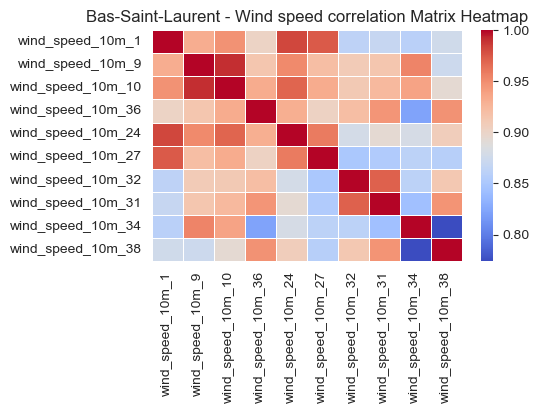

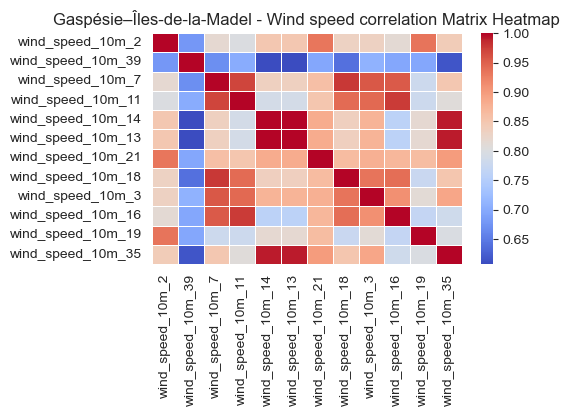

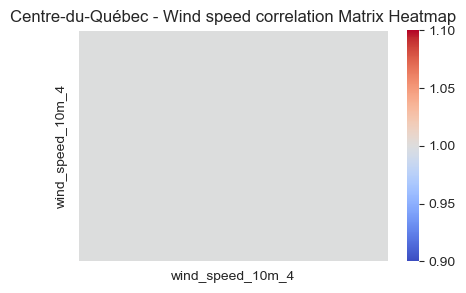

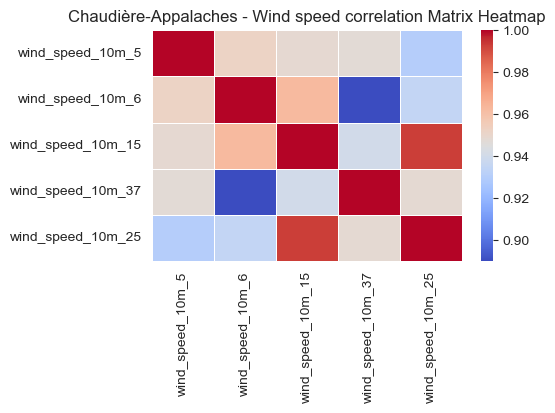

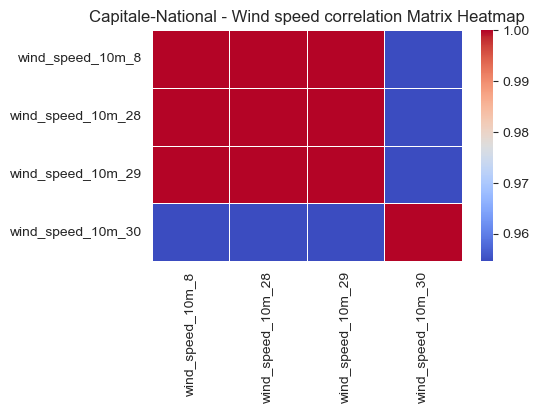

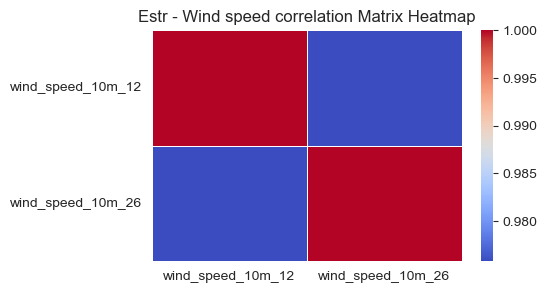

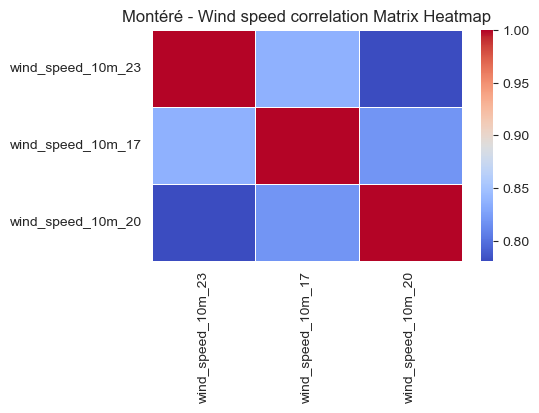

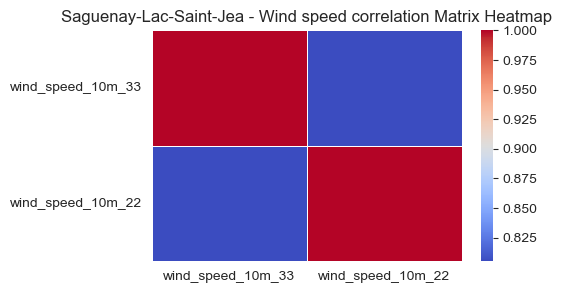

In [92]:
for reg in wc:
    plt.figure(figsize=(5, 3)) # Adjust figure size as needed
    sns.heatmap(wc[reg], annot=False, cmap='coolwarm', fmt=".2f", linewidths=.5)
    plt.title(f'{reg} - Wind speed correlation Matrix Heatmap')
    plt.show()

In [93]:
import plotly.graph_objects as go

fig = go.Figure()
for reg in df_wf.region.unique():
    fig.add_trace(go.Scattergeo(
            lat=df_wf.query(f'region=="{reg}"')['latitude'],
            lon=df_wf.query(f'region=="{reg}"')['longitude'],
            mode='markers',
            name=reg
            
        ))
    # fig.add_trace(go.Scattergeo(lat=df_wf_station.latitude_station, lon=df_wf_station.longitude_station))

fig.update_geos(fitbounds="locations") 

fig.show()



In [107]:
regions_labels = {}
for reg in df_wf.region.unique():
    print(reg)
    print(df_wf.query(f'region=="{reg}"').labels.unique())
    regions_labels[reg] = df_wf.query(f'region=="{reg}"').labels.unique()

## join regions that are close by
regions_labels['combined'] = np.append(regions_labels['Estr'], regions_labels['Centre-du-Québec'])
regions_labels['combined'] = np.append(regions_labels['combined'], regions_labels['Chaudière-Appalaches'])
regions_labels['combined1'] = np.append(regions_labels['Saguenay-Lac-Saint-Jea'], regions_labels['Capitale-National'])

regions_labels.pop('Centre-du-Québec')
regions_labels.pop('Estr')
regions_labels.pop('Chaudière-Appalaches')
regions_labels.pop('Capitale-National')
regions_labels.pop('Saguenay-Lac-Saint-Jea')

windcols = {}
for reg in regions_labels:
    windcols[reg] = []
    for col in daily:
        for label in regions_labels[reg]:
            if f'wind_speed_10m_{label}' == col:
                windcols[reg].append(col)

wc = {}
for reg in windcols:
    wc[reg] = daily[windcols[reg]].corr(numeric_only=True,)


Bas-Saint-Laurent
[ 1  9 10 24 27 31 32 34 36 38]
Gaspésie–Îles-de-la-Madel
[ 2  3  7 11 13 14 16 18 19 21 35 39]
Centre-du-Québec
[4]
Chaudière-Appalaches
[ 5  6 15 25 37]
Capitale-National
[ 8 28 29 30]
Estr
[12 26]
Montéré
[17 20 23]
Saguenay-Lac-Saint-Jea
[22 33]


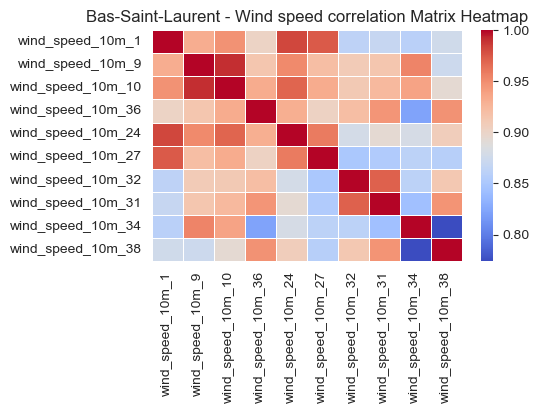

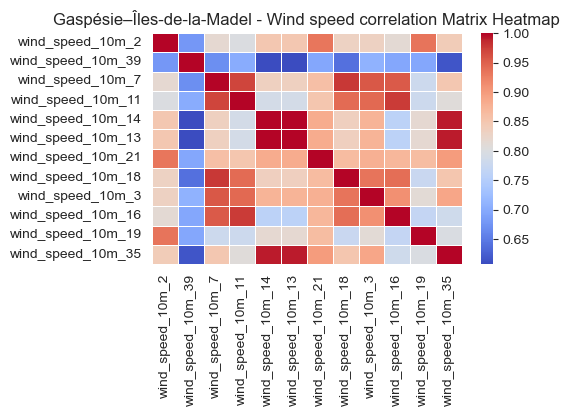

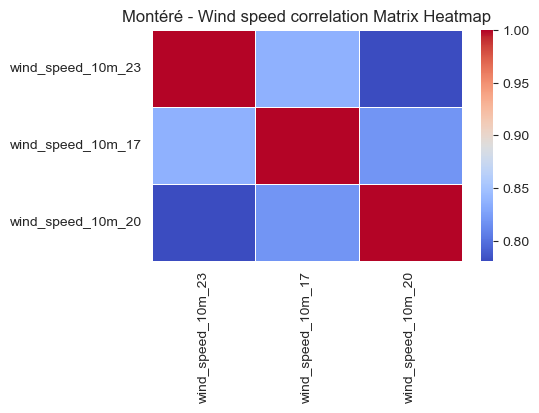

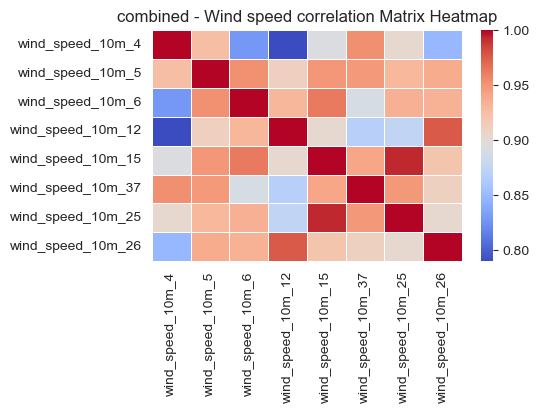

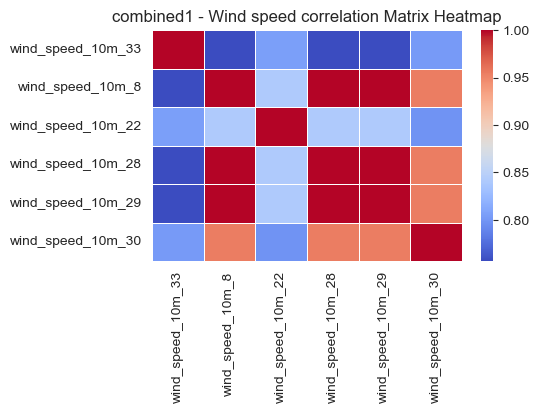

In [108]:
for reg in wc:
    plt.figure(figsize=(5, 3)) # Adjust figure size as needed
    sns.heatmap(wc[reg], annot=False, cmap='coolwarm', fmt=".2f", linewidths=.5)
    plt.title(f'{reg} - Wind speed correlation Matrix Heatmap')
    plt.show()

In [9]:
windcols = []
for col in daily:
    if 'wind_speed' in col:
        windcols.append(col)
wc = daily[windcols].corr(numeric_only=True,)

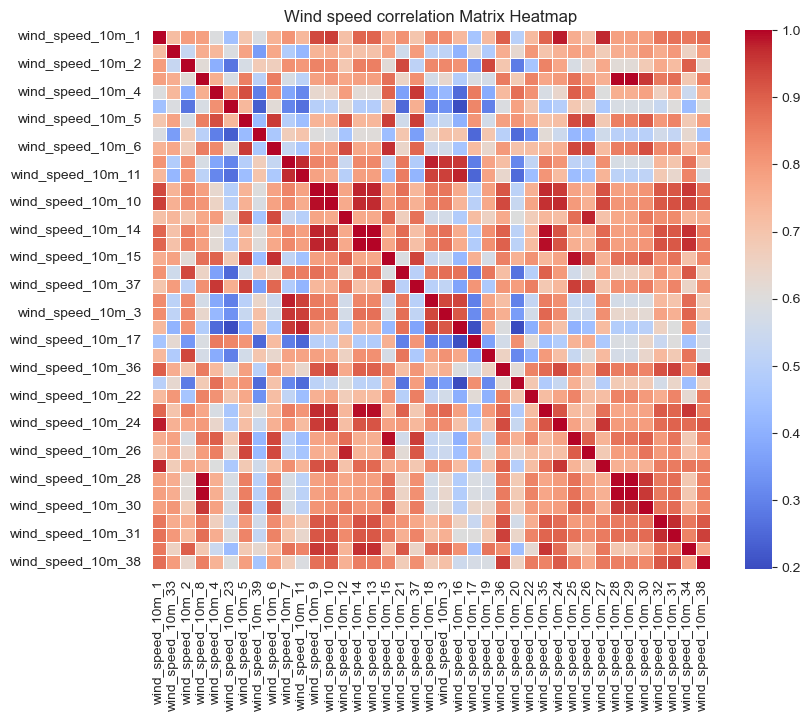

In [15]:
import seaborn as sns
plt.figure(figsize=(9, 7)) # Adjust figure size as needed
sns.heatmap(wc, annot=False, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Wind speed correlation Matrix Heatmap')
plt.show()

In [109]:
regions_labels

{'Bas-Saint-Laurent': array([ 1,  9, 10, 24, 27, 31, 32, 34, 36, 38]),
 'Gaspésie–Îles-de-la-Madel': array([ 2,  3,  7, 11, 13, 14, 16, 18, 19, 21, 35, 39]),
 'Montéré': array([17, 20, 23]),
 'combined': array([12, 26,  4,  5,  6, 15, 25, 37]),
 'combined1': array([22, 33,  8, 28, 29, 30])}

In [112]:
for reg in regions_labels:
    df[f'mws_{reg}'] = df[[f'wind_speed_10m_{i}' for i in regions_labels[reg]]].mean(axis=1)

numeric_cols = df.select_dtypes(include=['int64', 'float64'])
coldict = {}
for col in numeric_cols.columns:
    if col=='Wind':
        coldict[col] = 'sum'
    else:
        coldict[col] = 'mean'

daily = numeric_cols.resample('D').agg(coldict)

daily['day_of_year'] = daily.index.dayofyear
daily['year'] = daily.index.year
daily['month'] = daily.index.month

nfarms = 0
for column in df.columns:
    if 'temperature' in column:
        nfarms += 1
        
daily['mean_temperature'] = daily[[f'temperature_2m_{i}' for i in range(1, nfarms)]].mean(axis=1)
daily['mean_humidity'] = daily[[f'relative_humidity_2m_{i}' for i in range(1, nfarms)]].mean(axis=1)
daily['mean_windspeed'] = daily[[f'wind_speed_10m_{i}' for i in range(1, nfarms)]].mean(axis=1)

/var/folders/ft/qjyn_zl52k30krck3z17qrxm0000gn/T/ipykernel_33072/1549739364.py:2: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

/var/folders/ft/qjyn_zl52k30krck3z17qrxm0000gn/T/ipykernel_33072/1549739364.py:2: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

/var/folders/ft/qjyn_zl52k30krck3z17qrxm0000gn/T/ipykernel_33072/1549739364.py:2: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.co

In [114]:
daily

,Unnamed: 0,temperature_2m_1,relative_humidity_2m_1,wind_speed_10m_1,wind_direction_10m_1,temperature_2m_33,relative_humidity_2m_33,wind_speed_10m_33,wind_direction_10m_33,temperature_2m_2,...,mws_Gaspésie–Îles-de-la-Madel,mws_Montéré,mws_combined,mws_combined1,day_of_year,year,month,mean_temperature,mean_humidity,mean_windspeed
time,,,,,,,,,,,,,,,,,,,,,
2019-01-01,11.5,-6.870833,78.958333,18.620833,201.958333,-10.095833,77.375000,21.070833,237.250000,-9.137500,...,19.579514,21.072222,19.429167,18.151389,1,2019,1,-7.913706,82.041667,18.808882
2019-01-02,35.5,-18.062500,73.375000,14.770833,267.125000,-23.870833,69.166667,7.395833,212.291667,-20.029167,...,23.478125,8.229167,11.085417,10.892361,2,2019,1,-19.207237,70.584430,14.186294
2019-01-03,59.5,-16.054167,75.291667,7.262500,192.125000,-16.745833,72.750000,6.345833,111.458333,-19.991667,...,8.903819,9.270833,10.453125,10.461111,3,2019,1,-14.973246,75.842105,9.101206
2019-01-04,83.5,-5.525000,80.625000,15.316667,193.166667,-2.720833,79.375000,17.487500,206.583333,-11.970833,...,13.715625,15.455556,15.251042,18.207639,4,2019,1,-6.959978,85.791667,14.528947
2019-01-05,107.5,-1.354167,87.500000,8.012500,156.250000,-1.095833,83.666667,8.770833,227.666667,-5.329167,...,8.832639,6.761111,5.632292,6.703472,5,2019,1,-3.273355,89.582237,6.905592
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-12-27,34955.5,-10.358333,75.750000,14.195833,251.250000,-13.829167,73.958333,11.550000,246.416667,-12.854167,...,13.708681,12.515278,15.009375,14.709722,361,2022,12,-12.341996,79.491228,12.753070
2022-12-28,34979.5,-10.808333,78.916667,7.995833,216.041667,-11.025000,79.416667,6.350000,116.916667,-15.558333,...,12.706597,11.655556,9.261979,10.228472,362,2022,12,-11.882675,82.330044,9.547697
2022-12-29,35003.5,-6.879167,85.708333,8.100000,132.791667,-6.658333,87.208333,15.900000,106.000000,-11.633333,...,10.183681,11.740278,9.839062,11.332639,363,2022,12,-6.700219,85.621711,9.757127


In [115]:
regions_labels

{'Bas-Saint-Laurent': array([ 1,  9, 10, 24, 27, 31, 32, 34, 36, 38]),
 'Gaspésie–Îles-de-la-Madel': array([ 2,  3,  7, 11, 13, 14, 16, 18, 19, 21, 35, 39]),
 'Montéré': array([17, 20, 23]),
 'combined': array([12, 26,  4,  5,  6, 15, 25, 37]),
 'combined1': array([22, 33,  8, 28, 29, 30])}

In [117]:
mlr_model = LinearRegression()

mlr_model.fit(
    daily.query('year<2022')[[f'mws_{reg}' for reg in regions_labels]], daily.query('year<2022').Wind
)
preds = mlr_model.predict(daily.query('year==2022')[[f'mws_{reg}' for reg in regions_labels]])
print(mape(daily.query('year==2022').Wind.values, preds))
print(r2_score(daily.query('year==2022').Wind.values, preds))


0.22064667881585465
0.7971351414862887


In [118]:
mlr_model.coef_

array([1162.89266519,  781.59521638,  505.66045111,   48.82684904,
       1135.53562492])